In [1]:
# importr libraries

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


In [3]:
# load data

DATA_PATH = Path(r"C:\Users\User\OneDrive\Documents\OR PROJECTS\data\raw\telco_churn.csv")
df = pd.read_csv(DATA_PATH)

# Ensure target is binary numeric
df["Churn"] = (
    df["Churn"]
      .astype(str)
      .str.strip()
      .str.lower()
      .map({"yes": 1, "no": 0})
)

# sanity check
print(df["Churn"].value_counts(dropna=False))

# Convert TotalCharges safely
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.head()


Churn
0    5174
1    1869
Name: count, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [4]:
# test train split

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(y_train.mean(), y_test.mean())


0.2654297614539947 0.26519023282226006


In [5]:
# identify feature types

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

num_features, cat_features


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [6]:
# preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])


In [7]:
# Baseline Model — Logistic Regression

log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

roc_auc_lr


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8468222631880298

In [8]:
# Strong Model — Random Forest

rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

roc_auc_rf


0.840242727925626

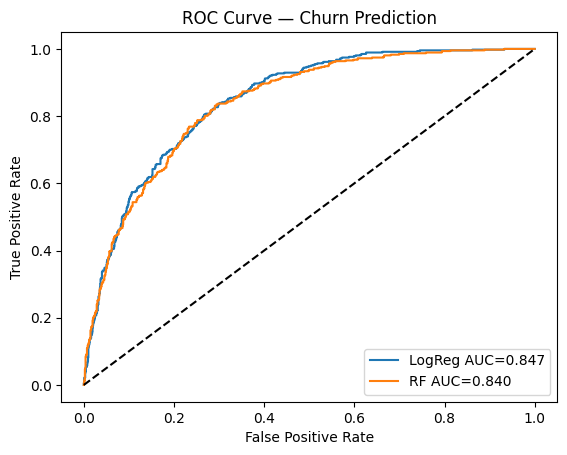

In [9]:
# roc comparison

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC={roc_auc_lr:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC={roc_auc_rf:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction")
plt.legend()
plt.show()


In [10]:
threshold = 0.30  # more aggressive retention strategy
y_pred_rf = (y_pred_proba_rf >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[846 448]
 [ 64 403]]
              precision    recall  f1-score   support

           0       0.93      0.65      0.77      1294
           1       0.47      0.86      0.61       467

    accuracy                           0.71      1761
   macro avg       0.70      0.76      0.69      1761
weighted avg       0.81      0.71      0.73      1761



Business Insight:
Customers on month-to-month contracts with high monthly charges and short tenure exhibit the highest churn risk.

By targeting the top 30% highest-risk customers identified by the model, retention teams can proactively intervene, potentially reducing churn-related revenue loss.

In [11]:
roc_auc_lr, roc_auc_rf

(0.8468222631880298, 0.840242727925626)